Que.1)  What is Boosting in Machine Learning? Explain how it improves weak learners.
Ans:- Boosting is an ensemble learning technique that combines multiple weak learners (models that perform only slightly better than random guessing) to create a strong learner with high predictive accuracy. It works by training models sequentially, where each new model focuses on correcting the errors made by the previous ones.

How Boosting Works :-
1. Start with a weak learner
- Typically a simple model like a decision stump (a one-level decision tree).
2. Assign weights to data points
- Initially, all samples are weighted equally.
- After each iteration, misclassified samples are given higher weights so the next learner pays more attention to them.
3. Train the next weak learner
- The new learner tries to minimize the errors of the previous one by focusing on the harder-to-classify examples.
4. Combine learners
- Each weak learner contributes to the final prediction, often with a weighted vote or weighted sum.
- The ensemble of weak learners becomes a strong model.

How Boosting Improves Weak Learners :-
- Error Reduction: By iteratively focusing on mistakes, boosting reduces bias and variance.
- Weighted Voting: Weak learners are combined intelligently, so even though each is weak, their collective decision is strong.
- Adaptive Learning: Boosting adapts to the data distribution, emphasizing difficult cases that single learners would ignore.
- Generalization: It prevents overfitting better than simply training one complex model, especially when regularization is applied (e.g., in XGBoost).

-------------------------------------------------------------------------------------------------------------------------------------------------------
Que.2)  What is the difference between AdaBoost and Gradient Boosting in terms of how models are trained? 
Ans:- Great question! Let’s break down the difference between AdaBoost and Gradient Boosting

A) AdaBoost (Adaptive Boosting)
1. Training Process:
- Starts with equal weights for all training samples.
- After each weak learner (often a decision stump) is trained, the weights of misclassified samples are increased.
- The next learner focuses more on these "hard" examples.

2. Error Handling:
- Learners are combined using weighted voting, where better-performing learners get higher influence.
- The emphasis is on re-weighting data points to adaptively correct mistakes.

B) Gradient Boosting
1. Training Process:
- Instead of re-weighting samples, Gradient Boosting fits each new learner to the residual errors (the difference between predicted and actual values).
- It uses gradient descent to minimize a chosen loss function (e.g., mean squared error for regression, log-loss for classification).

2. Error Handling:
- Each learner is trained to predict the residuals of the previous model.
- The final model is the sum of all learners, gradually reducing the loss.
- The emphasis is on optimizing the loss function directly.

-------------------------------------------------------------------------------------------------------------------------------------------------------
Que.3) How does regularization help in XGBoost?
Ans:- XGBoost (Extreme Gradient Boosting) is a powerful boosting algorithm, but without control it can easily overfit the training data. Regularization is built into XGBoost to prevent this and improve generalization.

How Regularization Helps:- 
1. Controls Model Complexity
- XGBoost adds penalty terms to the objective function for overly complex trees.
- This discourages deep or overly branched trees that memorize training data.

2. Shrinkage (Learning Rate)
- After each boosting step, predictions are scaled down by a factor (learning rate).
- This slows down learning, forcing the model to combine many small improvements rather than a few large, unstable ones.

3. L1 Regularization (Lasso)
- Encourages sparsity in leaf weights.
- Some leaf weights may shrink to zero, simplifying the model.

4. L2 Regularization (Ridge)
- Smooths leaf weights by penalizing large values.
- Prevents extreme predictions and stabilizes training.

5. Column Subsampling
- Randomly selects subsets of features for each tree.
- Reduces correlation among trees and improves robustness.

-------------------------------------------------------------------------------------------------------------------------------------------------------
Que.4) Why is CatBoost considered efficient for handling categorical data? 
Ans:- CatBoost (short for Categorical Boosting) is a gradient boosting library designed specifically to handle categorical features efficiently, without requiring heavy preprocessing like one-hot encoding. Here’s why it stands out:

Key Advantages:-
1. Native Handling of Categorical Features
- Unlike XGBoost or LightGBM, CatBoost doesn’t need manual encoding (like one-hot or label encoding).
- It uses a technique called ordered target statistics (or target-based encoding) that transforms categorical values into numerical representations based on their relationship with the target variable.

2. Avoids Overfitting with Ordered Encoding
- Standard target encoding can cause data leakage (using target info from the same row).
- CatBoost solves this by applying ordered boosting, where encoding is done using only past data points in a random permutation, preventing leakage and overfitting.

3. Efficient Training
- CatBoost uses symmetric trees (balanced splits at each level), which makes training faster and predictions more efficient.
- It reduces memory usage compared to one-hot encoding, especially when categorical features have high cardinality (many unique values).

4. Better Accuracy on Real-World Data
- Since many datasets (like customer IDs, product categories, ZIP codes) are categorical, CatBoost often outperforms other boosting methods without extensive preprocessing.
- It’s particularly strong in domains like finance, e-commerce, and recommendation systems.

-------------------------------------------------------------------------------------------------------------------------------------------------------
Que.5) What are some real-world applications where boosting techniques are preferred over bagging methods?
Ans:- Boosting techniques (like AdaBoost, Gradient Boosting, XGBoost, CatBoost) are often chosen over bagging methods (like Random Forests) when the goal is to reduce bias and improve predictive accuracy in complex datasets. Here are some domains where boosting shines:

1. Finance & Banking
- Credit Scoring & Fraud Detection  
Boosting models capture subtle patterns in transaction data, making them highly effective for detecting fraudulent activity or predicting loan defaults.
- Bagging (Random Forests) is good for stability, but boosting often achieves higher accuracy in imbalanced datasets.

2. Healthcare
- Disease Prediction & Medical Imaging  
Boosting is used to predict patient outcomes, classify medical images, and detect anomalies in scans.
- Its ability to focus on hard-to-classify cases (like rare diseases) makes it more suitable than bagging.

3. E-Commerce & Marketing
- Recommendation Systems & Customer Churn Prediction  
Boosting models (especially CatBoost) handle categorical features like product IDs, customer segments, and regions efficiently.
- They outperform bagging when the dataset has many categorical variables with complex interactions.

4. Natural Language Processing (NLP)
- Sentiment Analysis & Text Classification  
Boosting can capture nuanced relationships in textual features.
- Bagging methods may miss subtle distinctions, while boosting adapts to misclassified text samples.

5. Cybersecurity
- Intrusion Detection Systems  
Boosting is effective in identifying rare attack patterns by focusing on misclassified cases.
- Bagging provides robustness, but boosting achieves higher sensitivity in detecting threats.

Why Boosting Over Bagging:- 
- Bagging reduces variance by averaging many models → great for noisy datasets.
- Boosting reduces bias by sequentially improving weak learners → great for complex, structured problems where accuracy matters most.

In [1]:
#Datasets: 
#● Use sklearn.datasets.load_breast_cancer() for classification tasks. 
#● Use sklearn.datasets.fetch_california_housing() for regression tasks. 
#Que.6) Write a Python program to: 
#● Train an AdaBoost Classifier on the Breast Cancer dataset 
#● Print the model accuracy 
#Ans:-

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score

# Load dataset
data = load_breast_cancer()
X, y = data.data, data.target

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Initialize AdaBoost Classifier
model = AdaBoostClassifier(
    n_estimators=100,      # number of weak learners
    learning_rate=0.5,     # shrinkage parameter
    random_state=42
)

# Train the model
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Print accuracy
accuracy = accuracy_score(y_test, y_pred)
print("AdaBoost Classifier Accuracy on Breast Cancer dataset:", accuracy)


AdaBoost Classifier Accuracy on Breast Cancer dataset: 0.9649122807017544


In [3]:
#Que.7)  Write a Python program to: 
#● Train a Gradient Boosting Regressor on the California Housing dataset 
#● Evaluate performance using R-squared score
#Ans:-

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score

# Load dataset
data = fetch_california_housing()
X, y = data.data, data.target

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Initialize Gradient Boosting Regressor
model = GradientBoostingRegressor(
    n_estimators=200,     # number of boosting stages
    learning_rate=0.1,    # shrinkage parameter
    max_depth=4,          # depth of individual regression estimators
    random_state=42
)

# Train the model
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Evaluate performance using R² score
r2 = r2_score(y_test, y_pred)
print("Gradient Boosting Regressor R² score on California Housing dataset:", r2)


Gradient Boosting Regressor R² score on California Housing dataset: 0.8185494799226947


In [4]:
#Que.8) Write a Python program to: 
#● Train an XGBoost Classifier on the Breast Cancer dataset 
#● Tune the learning rate using GridSearchCV 
#● Print the best parameters and accuracy 
#Ans:- 

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

# Load dataset
data = load_breast_cancer()
X, y = data.data, data.target

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Initialize XGBoost Classifier
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

# Define parameter grid for learning rate
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3]
}

# GridSearchCV for tuning
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Fit the model
grid_search.fit(X_train, y_train)

# Best parameters
print("Best Parameters:", grid_search.best_params_)

# Predict on test set
y_pred = grid_search.best_estimator_.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("XGBoost Classifier Accuracy on Breast Cancer dataset:", accuracy)


Best Parameters: {'learning_rate': 0.3}
XGBoost Classifier Accuracy on Breast Cancer dataset: 0.956140350877193


C:\Users\Shravani\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:52:27] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


CatBoost Classifier Accuracy on Breast Cancer dataset: 0.9649122807017544


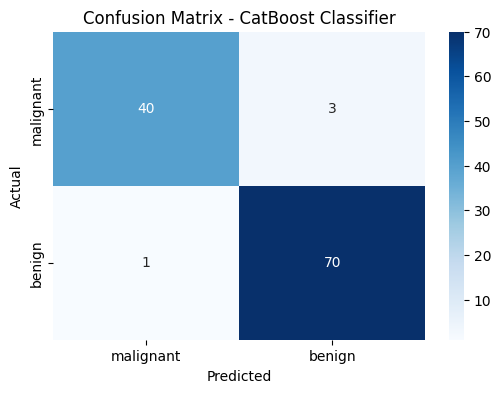

In [5]:
#Que.9) Write a Python program to: 
#● Train a CatBoost Classifier 
#● Plot the confusion matrix using seaborn
#Ans:-

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier

# Load dataset
data = load_breast_cancer()
X, y = data.data, data.target

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Initialize CatBoost Classifier
model = CatBoostClassifier(
    iterations=200,
    learning_rate=0.1,
    depth=4,
    verbose=0,          # suppress training output
    random_state=42
)

# Train the model
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("CatBoost Classifier Accuracy on Breast Cancer dataset:", accuracy)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix using seaborn
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=data.target_names,
            yticklabels=data.target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - CatBoost Classifier")
plt.show()


#Que.10)You're working for a FinTech company trying to predict loan default using customer demographics and transaction behavior. The dataset is imbalanced, contains missing values, and has both numeric and categorical features. 
#Describe your step-by-step data science pipeline using boosting techniques: 
#● Data preprocessing & handling missing/categorical values 
#● Choice between AdaBoost, XGBoost, or CatBoost 
#● Hyperparameter tuning strategy 
#● Evaluation metrics you'd choose and why 
#● How the business would benefit from your model
#Ans:- 

1. Data Preprocessing
- Handle Missing Values
    - Numeric features → impute with median (robust to outliers).
    - Categorical features → impute with mode or introduce a special category like "Unknown".
- Feature Scaling
    - Boosting methods don’t strictly require scaling, but normalization can help with interpretability.
- Categorical Encoding
    - If using CatBoost → no manual encoding needed.
    - If using XGBoost/AdaBoost → apply one-hot encoding or target encoding for high-cardinality features.
- Class Imbalance
    - Use techniques like SMOTE (oversampling), undersampling, or class weights in the boosting algorithm to balance default vs non-default cases.

2. Choice of Boosting Algorithm
- AdaBoost: Works well with clean, balanced datasets but struggles with missing values and categorical features.
- XGBoost: Powerful, handles missing values internally, great for numeric-heavy datasets.
- CatBoost: Best suited here because your dataset has both numeric and categorical features and is imbalanced. CatBoost’s ordered boosting avoids target leakage and handles categorical variables natively.
- Preferred choice: CatBoost for efficiency and accuracy in mixed-type, imbalanced datasets.

3. Hyperparameter Tuning Strategy
- Use GridSearchCV or RandomizedSearchCV for initial exploration.
- Key parameters to tune:
   - learning_rate → controls shrinkage (start with 0.01–0.3).
   - depth → tree depth (3–10).
   - iterations → number of boosting rounds (100–1000).
   - l2_leaf_reg → regularization strength.
   - class_weights → balance default vs non-default classes.
   - For efficiency, switch to Bayesian Optimization (e.g., Optuna) after narrowing ranges.

4. Evaluation Metrics
Since the dataset is imbalanced, accuracy alone is misleading.
- Primary Metrics:
    - AUC-ROC → measures ability to distinguish default vs non-default.
    - Precision-Recall (PR AUC) → more informative when defaults are rare.
- Secondary Metrics:
    - F1-score → balances precision and recall.
    - Confusion Matrix → interprets false positives vs false negatives.
- Business context: False negatives (predicting “no default” when default occurs) are more costly than false positives. So recall and PR AUC are critical.

5. Business Benefits
- Risk Management: More accurate default prediction reduces financial losses.
- Customer Segmentation: Identify high-risk borrowers for stricter credit policies.
- Profitability: Approve more loans safely by distinguishing genuine customers from risky ones.
- Trust & Compliance: Transparent boosting models (with SHAP values for explainability) help meet regulatory requirements.